In [224]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import title
from sklearn.preprocessing import MinMaxScaler


In [225]:
df=pd.read_csv("../docs/oldDocs/Mall_Customers.csv", na_values=['-', ' ', '', '/', 'NA', 'null'])

In [226]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [227]:
df.drop(columns='CustomerID',inplace=True)

In [228]:
df['Gender']

0        Male
1        Male
2      Female
3      Female
4      Female
        ...  
195    Female
196    Female
197      Male
198      Male
199      Male
Name: Gender, Length: 200, dtype: object

In [229]:
df['Gender']=df['Gender'].map({'Female':1,'Male':0})

In [230]:
df.info()#izmapirali smo gender na 0 1 da bude kategorijska numericka ... izbacili smo customer id jer ne doprinisi modelu jer nam id kupca nista ne govori ...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [231]:
#nema Na vrednosti ..

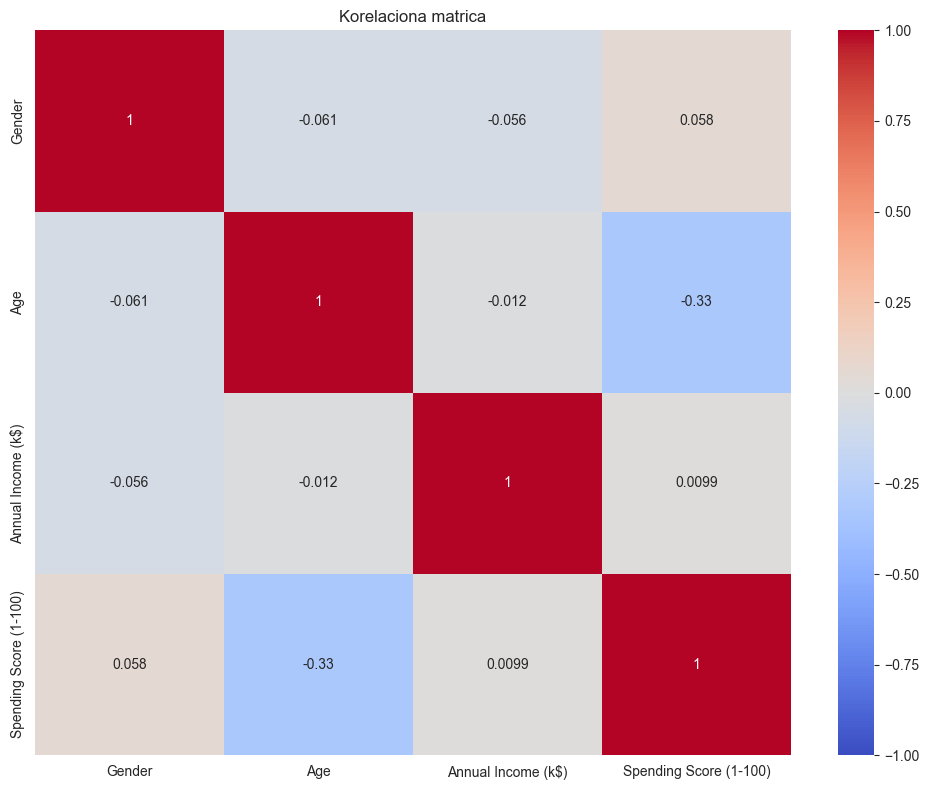

In [232]:
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [233]:
#Korelaciona matrica nam ne pokazuje nikakve zavitnosti izmedju atributa tako da ne cemo da izbacimo nista na osnovu ove matrice ... niko nije preterano korelaisan
#jedino age -0.33 ali to ipak nije dovoljna korelacija za izbacivanje ...

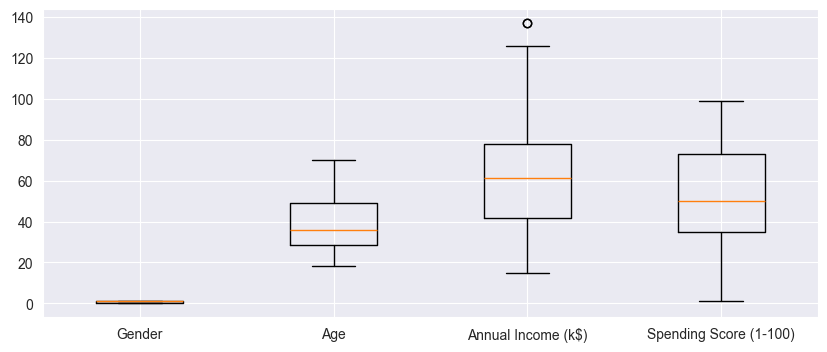

In [234]:
#provera outliera
plt.figure(figsize=(10,4))
plt.boxplot(x=df,tick_labels=df.columns)
plt.show()
#vidimo na osnovu box plota da annual income ima samo jednog outlierea

In [235]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [236]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(df['Annual Income (k$)'],limits=[0,0.0100])

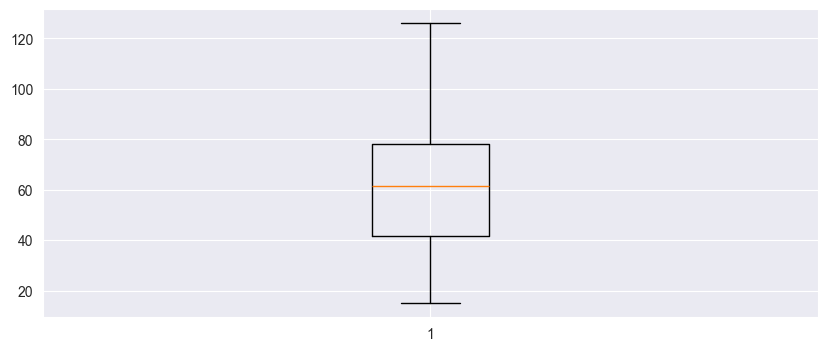

In [237]:
#provera outliera
plt.figure(figsize=(10,4))
plt.boxplot(x=wins)
plt.show()
#vidimo na osnovu box plota da annual income ima samo jednog outlierea

In [238]:
df['Annual Income (k$)']=wins

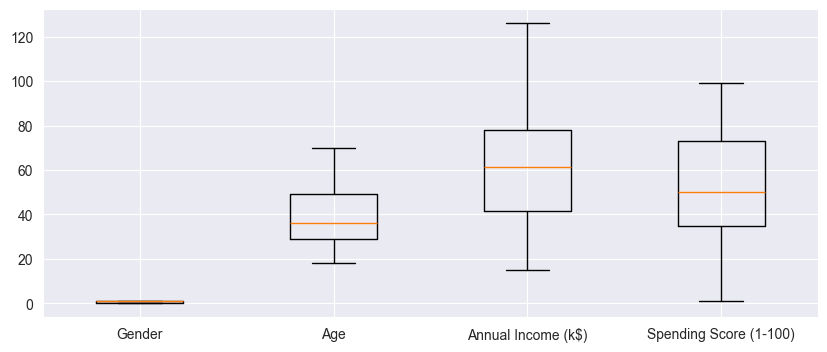

In [239]:
#provera outliera
plt.figure(figsize=(10,4))
plt.boxplot(x=df,tick_labels=df.columns)
plt.show()
#vidimo na osnovu box plota da vise nemamo outlieara ...

In [240]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_scaled=pd.DataFrame(data=scaler.fit_transform(df),columns=df.columns)

In [241]:
#moramo da skaliramo sa minmax scaleromo u Kmeans algoritmu zato sto ... ne znam ovo reci mi claude

In [242]:
wcss=[]
from sklearn.cluster import KMeans

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(df_scaled)
    wcss.append(kmeans.inertia_)


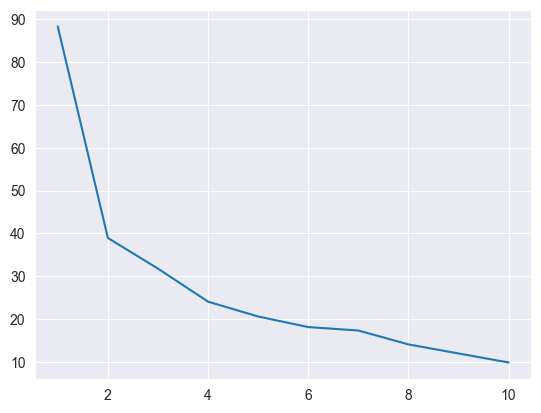

In [243]:
plt.plot(range(1,11),wcss)

In [244]:
#najveci lakat koji vidim na elbow metodi je na 2 klustera ali bi se moglo videti i na 4 probacemo obe varijante

In [245]:
kmeansNovi = KMeans(n_clusters=4, random_state=42).fit(df_scaled)
df['clusters']=kmeansNovi.labels_

In [275]:
df_scaled['clusters']=kmeansNovi.labels_

In [246]:
print(df['clusters'].value_counts())

clusters
2    57
1    55
0    48
3    40
Name: count, dtype: int64


In [247]:
#imamo 112 klastera prvog tipa i 88 klastera 0 tipa kada smo stavili broj klastera 2

In [248]:
print(df.groupby('clusters').std())

          Gender        Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                               
0            0.0  14.028703           24.031589               19.266284
1            0.0   9.836954           25.771856               16.465104
2            0.0   5.493560           26.463812               18.712255
3            0.0   6.975231           28.435250               16.727664


In [249]:
print(df.groupby('clusters').mean())

          Gender        Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                               
0            0.0  49.437500           62.187500               29.208333
1            1.0  48.109091           58.818182               34.781818
2            1.0  28.438596           59.666667               67.684211
3            0.0  28.250000           61.725000               71.675000


In [250]:
#klasteri su podeljieni na muskarce i zene samo drugih razlika i nema u modelu sa 2 klustera

In [251]:
# sa 4 klustera imamo
# 2 klastera muskaraca sa malim spending scorom i velikim spending scorom istim annual income oni koje visie trose i mladi su u proseku 28 godina
# 2 klastera zena starih 49 i 28 godina .. gde starije zene malo manje trose 29 od 100 spending score a mladje zene vise trose 71 od 100 spending score ...

<Figure size 1200x1000 with 0 Axes>

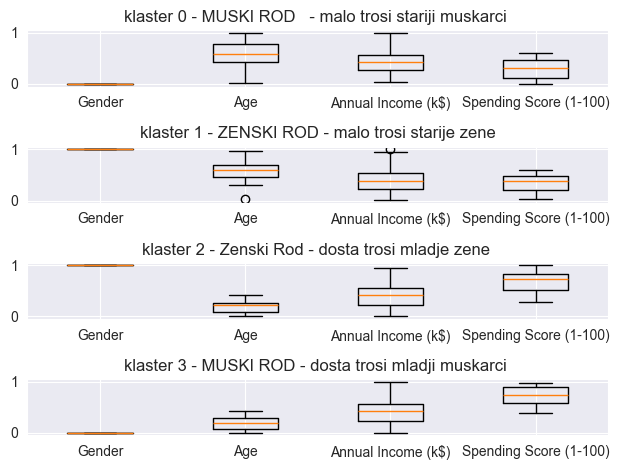

In [280]:
plt.figure(figsize=(12, 10))
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)

ax1.boxplot(x=df_scaled[df_scaled['clusters']==0].drop(columns='clusters'), tick_labels=df_scaled.drop(columns='clusters').columns)
ax1.set_title("klaster 0 - MUSKI ROD   - malo trosi stariji muskarci ")
ax2.boxplot(x=df_scaled[df_scaled['clusters']==1].drop(columns='clusters'), tick_labels=df_scaled.drop(columns='clusters').columns)
ax2.set_title("klaster 1 - ZENSKI ROD - malo trosi starije zene")
ax3.boxplot(x=df_scaled[df_scaled['clusters']==2].drop(columns='clusters'), tick_labels=df_scaled.drop(columns='clusters').columns)
ax3.set_title("klaster 2 - Zenski Rod - dosta trosi mladje zene ")
ax4.boxplot(x=df_scaled[df_scaled['clusters']==3].drop(columns='clusters'), tick_labels=df_scaled.drop(columns='clusters').columns)
ax4.set_title("klaster 3 - MUSKI ROD - dosta trosi mladji muskarci ")
plt.tight_layout()
plt.show()
#1 zenski rod 0 muski rod

In [281]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df_scaled.drop(columns='clusters'), df['clusters'])
print(f'Silhouette Score: {score:.3f}')
# Vrijednost blizu 1 = dobra separacija klastera
# Vrijednost blizu 0 = klasteri se preklapaju
# Vrijednost negativna = losija klasterizacija

Silhouette Score: 0.352
